In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import RectBivariateSpline
from scipy.interpolate import interp2d
import datetime
from unwrap import unwrap
from scipy.interpolate import griddata

In [2]:
NF_data = np.load('/hirax/20220916_WLC_NFandFF/NF_Map_220916.npz',allow_pickle=True)
NF_data.files

['t',
 'x',
 'y',
 'z',
 'V',
 'V_bgsub',
 'V_bg',
 'V_cross',
 'V_cross_bgsub',
 'V_cross_bg',
 'i_on',
 'f']

In [3]:
x = NF_data['x']
condition = np.isnan(x)==False
x_real = x[condition]
print(x_real)
print(x_real.shape)
print(NF_data['V_bgsub'].shape)
print(NF_data['V_cross_bgsub'].shape)
print(NF_data['x'].shape)
print(NF_data['y'].shape)
print(NF_data['t'].shape)

[37.62211052 37.62117882 37.62061707 ... 44.20691037 44.20706099
 44.2068282 ]
(32148,)
(48576, 400, 2)
(48576, 400, 1)
(48576,)
(48576,)
(48576,)


In [4]:
(NF_data['z'])[np.logical_not((np.isnan(NF_data['z'])))]

array([-2.14143192, -2.14274389, -2.14353493, ..., -2.21812179,
       -2.2176722 , -2.21760047])

In [5]:
# NF_amplitude = np.sqrt(NF_data['V_bgsub'])
# NF_amplitude = np.lib.scimath.sqrt(NF_data['V_bgsub'])
NF_amplitude = NF_data['V_bgsub']
NF_amplitude.shape
print(len(NF_amplitude[np.isnan(NF_amplitude)]))

NF_phase = NF_data['V_cross_bgsub']
print(NF_phase.shape)

NF_complex = NF_amplitude[:,:,1]*np.cos(NF_phase[:,:,0]) + 1j*NF_amplitude[:,:,1]*np.sin(NF_phase[:,:,0])

0
(48576, 400, 1)


[datetime.datetime(2022, 9, 16, 18, 19, 19, 32710, tzinfo=<UTC>)
 datetime.datetime(2022, 9, 16, 18, 19, 19, 74653, tzinfo=<UTC>)
 datetime.datetime(2022, 9, 16, 18, 19, 19, 116596, tzinfo=<UTC>) ...
 datetime.datetime(2022, 9, 16, 18, 53, 16, 331992, tzinfo=<UTC>)
 datetime.datetime(2022, 9, 16, 18, 53, 16, 373935, tzinfo=<UTC>)
 datetime.datetime(2022, 9, 16, 18, 53, 16, 415878, tzinfo=<UTC>)]


<ipython-input-6-35f29d842d19>:13: RuntimeWarning: divide by zero encountered in log10
  ax.scatter((NF_data['x'])[19450:36750],(NF_data['y'])[19450:36750],c=20*np.log10(NF_amplitude[19450:36750,275,1]))
<ipython-input-6-35f29d842d19>:13: RuntimeWarning: invalid value encountered in log10
  ax.scatter((NF_data['x'])[19450:36750],(NF_data['y'])[19450:36750],c=20*np.log10(NF_amplitude[19450:36750,275,1]))
/home/am3674/anaconda3/lib/python3.8/site-packages/numpy/core/_asarray.py:171: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order, subok=True)
<ipython-input-6-35f29d842d19>:25: RuntimeWarning: divide by zero encountered in log10
  ax.scatter((NF_data['x'])[19450:36750],(NF_data['y'])[19450:36750],c=20*np.log10(np.abs(NF_complex[19450:36750,275])))


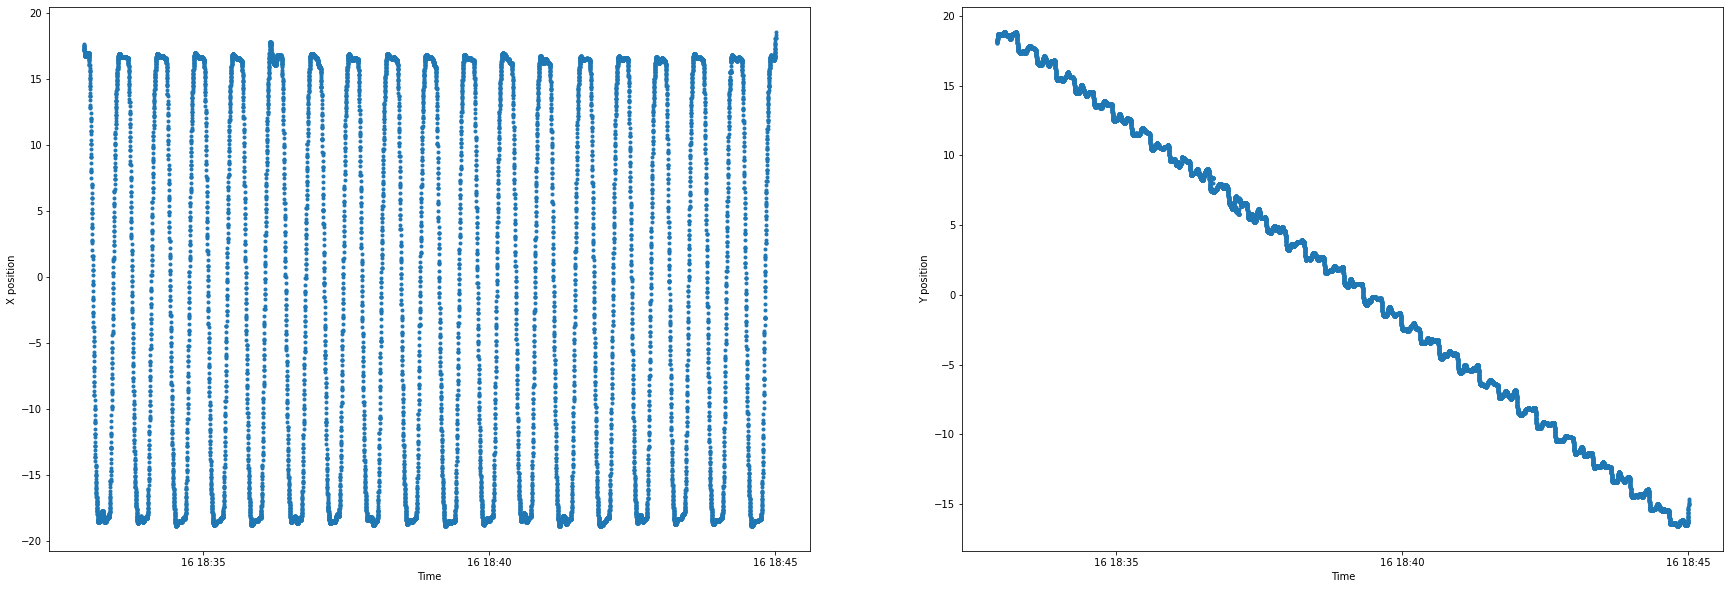

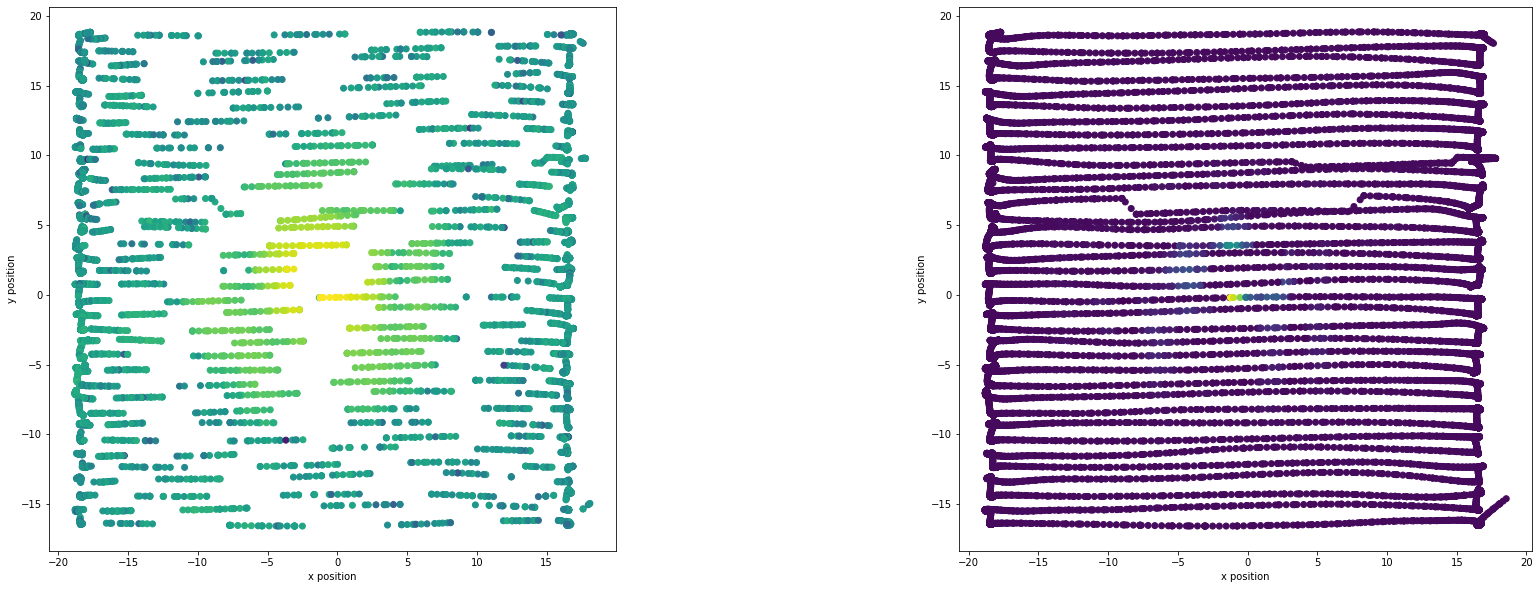

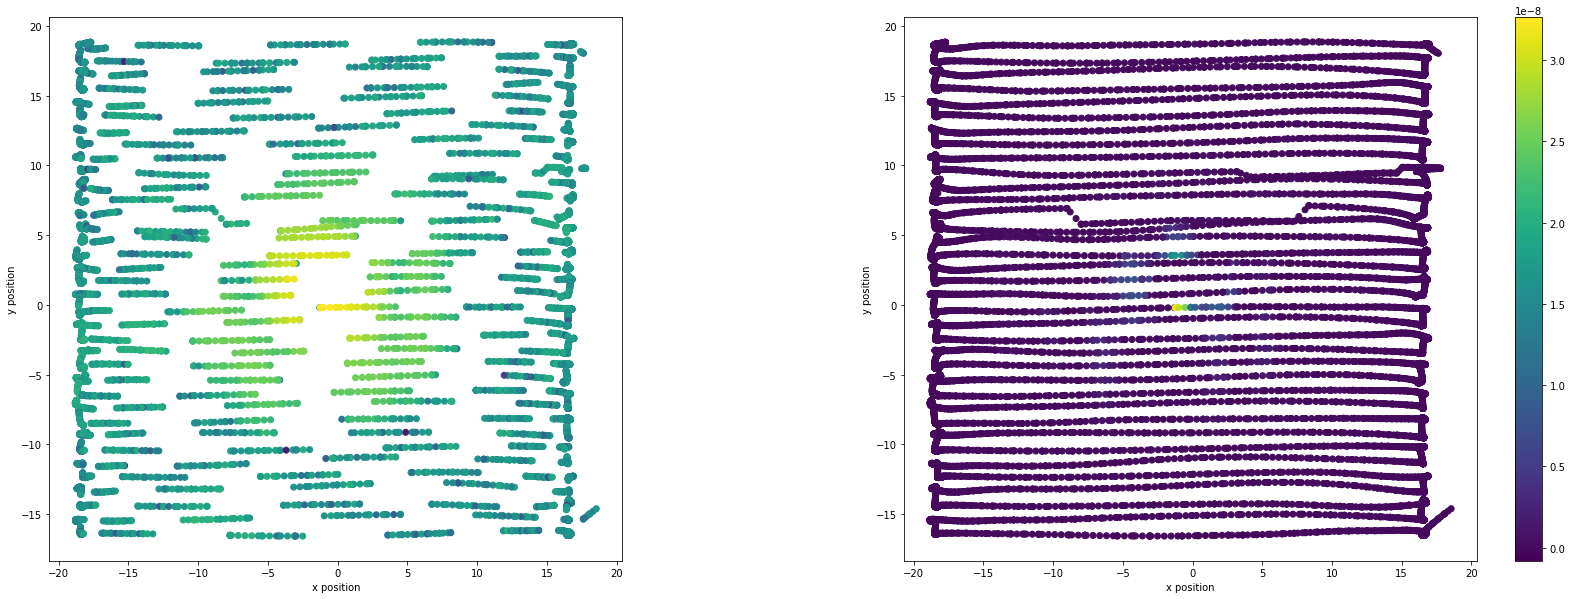

In [6]:
# plotting x and y position over time
fig,ax = plt.subplots(1,2,figsize=(30,10))
ax[0].plot((NF_data['t'][19450:36750]),(NF_data['x'])[19450:36750],'.')
print(NF_data['t'])
ax[0].set_xlabel('Time')
ax[0].set_ylabel('X position')
ax[1].plot((NF_data['t'])[19450:36750],(NF_data['y'])[19450:36750],'.')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Y position')

fig = plt.figure(figsize=(30,10))
ax = fig.add_subplot(1,2,1)
ax.scatter((NF_data['x'])[19450:36750],(NF_data['y'])[19450:36750],c=20*np.log10(NF_amplitude[19450:36750,275,1]))
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax = fig.add_subplot(1,2,2)
ax.scatter((NF_data['x'])[19450:36750],(NF_data['y'])[19450:36750],c=NF_phase[19450:36750,275])
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')

fig=plt.figure(figsize=(30,10))
ax = fig.add_subplot(1,2,1)
ax.scatter((NF_data['x'])[19450:36750],(NF_data['y'])[19450:36750],c=20*np.log10(np.abs(NF_complex[19450:36750,275])))
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax = fig.add_subplot(1,2,2)
pcm=ax.scatter((NF_data['x'])[19450:36750],(NF_data['y'])[19450:36750],c=NF_phase[19450:36750,275])
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')
plt.colorbar(mappable=pcm)

In [7]:
help(RectBivariateSpline)

Help on class RectBivariateSpline in module scipy.interpolate.fitpack2:

class RectBivariateSpline(BivariateSpline)
 |  RectBivariateSpline(x, y, z, bbox=[None, None, None, None], kx=3, ky=3, s=0)
 |  
 |  Bivariate spline approximation over a rectangular mesh.
 |  
 |  Can be used for both smoothing and interpolating data.
 |  
 |  Parameters
 |  ----------
 |  x,y : array_like
 |      1-D arrays of coordinates in strictly ascending order.
 |  z : array_like
 |      2-D array of data with shape (x.size,y.size).
 |  bbox : array_like, optional
 |      Sequence of length 4 specifying the boundary of the rectangular
 |      approximation domain.  By default,
 |      ``bbox=[min(x), max(x), min(y), max(y)]``.
 |  kx, ky : ints, optional
 |      Degrees of the bivariate spline. Default is 3.
 |  s : float, optional
 |      Positive smoothing factor defined for estimation condition:
 |      ``sum((z[i]-f(x[i], y[i]))**2, axis=0) <= s`` where f is a spline
 |      function. Default is ``s=0`

In [8]:
NF_complex_grid = NF_complex[19450:36750,:]
x_grid = (NF_data['x'])[19450:36750]
y_grid = (NF_data['y'])[19450:36750]
t_grid = (NF_data['z'])[19450:36750]

In [9]:
NF_real_grid = NF_complex_grid.real
NF_im_grid = NF_complex_grid.imag

print(len(NF_data['x']))
print(len(NF_data['y']))

# NF_real_interp = interp2d(x_grid,y_grid,NF_real_grid[:,275],kind='quintic')
# NF_im_interp = interp2d(x_grid,y_grid,NF_im_grid[:,275],kind='quintic')

x_interp = np.linspace(-15,15,50)
y_interp = np.linspace(-15,15,50)

[x_interp_grid,y_interp_grid]=np.meshgrid(x_interp,y_interp)

NF_real_interp = griddata((x_grid,y_grid),NF_real_grid[:,275],(x_interp_grid,y_interp_grid))
NF_im_interp = griddata((x_grid,y_grid),NF_im_grid[:,275],(x_interp_grid,y_interp_grid))

48576
48576


In [10]:
# x_interp = np.linspace(-15,15,50)
# y_interp = np.linspace(-15,15,50)

# [x_interp_grid,y_interp_grid]=np.meshgrid(x_interp,y_interp)

# NF_real_interped = NF_real_interp(x_interp,y_interp)
# NF_im_interped = NF_im_interp(x_interp,y_interp)

NF_interped = NF_real_interp + 1j*NF_im_interp
NF_interped_amplitude = np.abs(NF_interped)

In [11]:
NF_real_grid.shape

(17300, 400)

In [12]:
x_interp_grid.shape
NF_interped.shape

(50, 50)

<ipython-input-13-5e54ba67c369>:8: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax.pcolormesh(x_interp_grid,y_interp_grid,NF_interped_amplitude)
<ipython-input-13-5e54ba67c369>:20: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax.pcolormesh(x_interp_grid,y_interp_grid,np.unwrap(np.angle(NF_interped)))


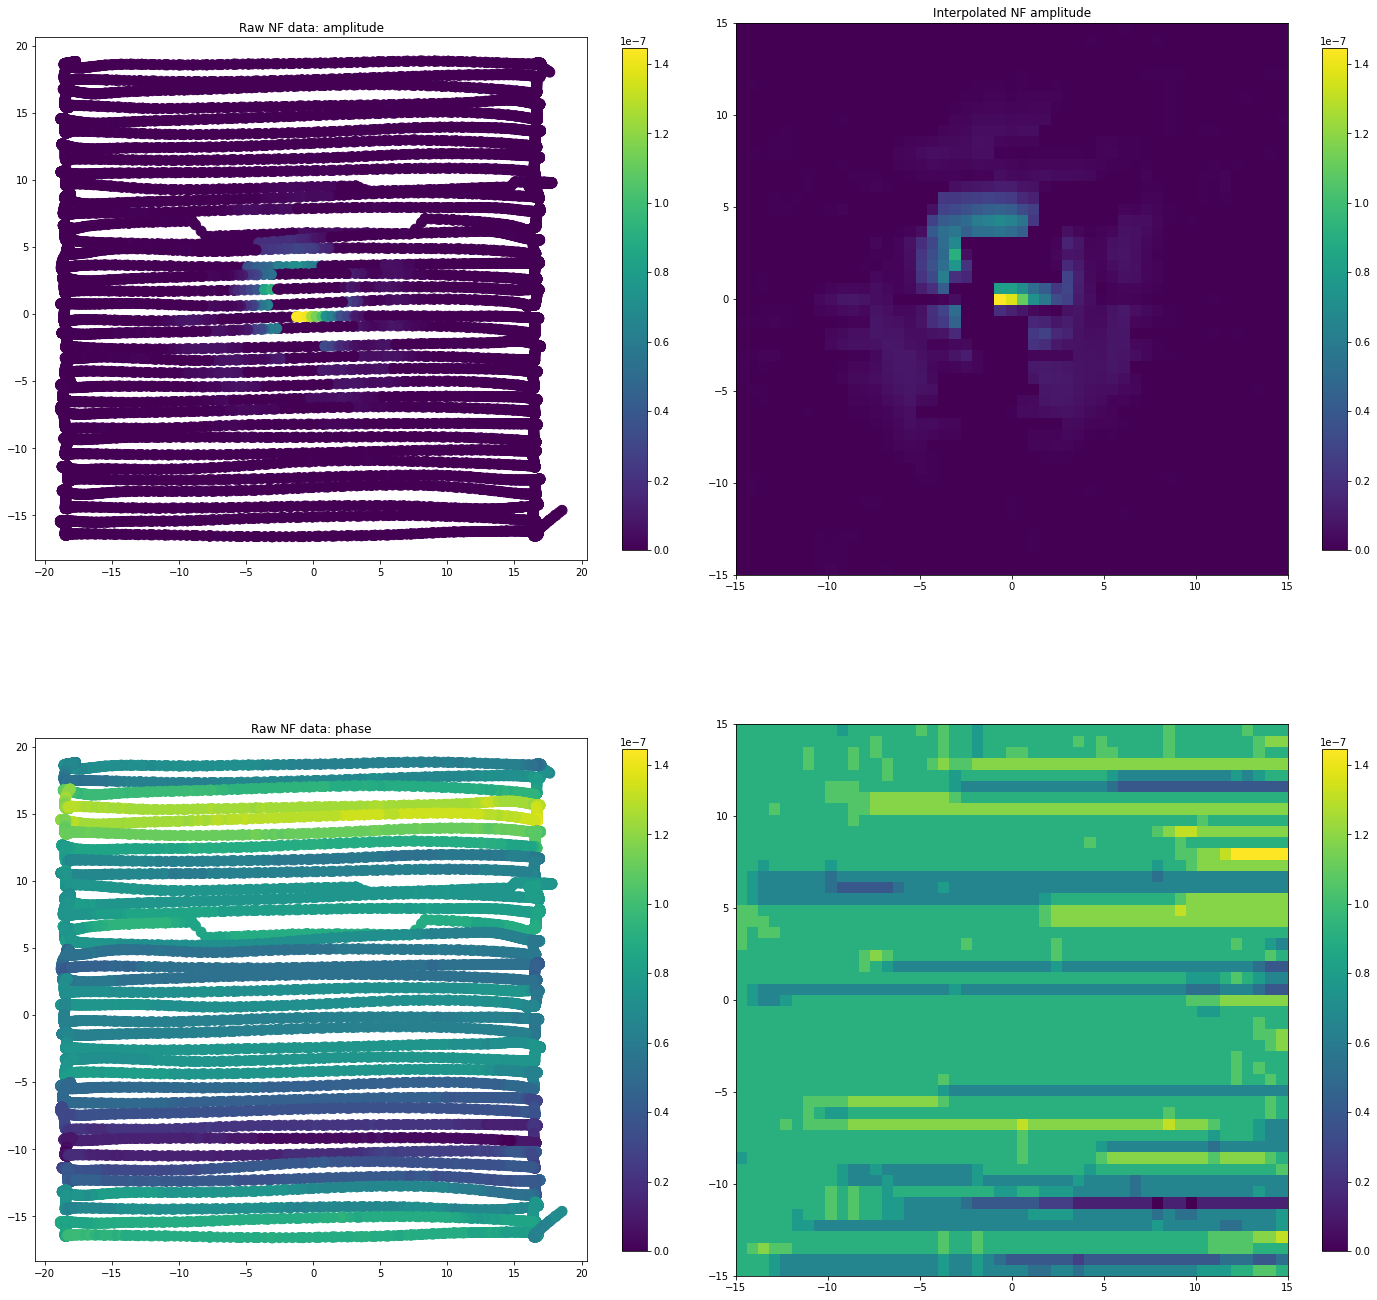

In [13]:
fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(2,2,1)
plt.scatter(x_grid,y_grid,c=np.abs(NF_complex_grid[:,275]),s=100)
ax.set_aspect('equal')
plt.colorbar(shrink=0.7)
plt.title('Raw NF data: amplitude')
ax = fig.add_subplot(2,2,2)
ax.pcolormesh(x_interp_grid,y_interp_grid,NF_interped_amplitude)
plt.title('Interpolated NF amplitude')
plt.colorbar(shrink=0.7)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('NF_vs_interpolated_data.jpg')
ax = fig.add_subplot(2,2,3)
ax.scatter(x_grid,y_grid,c=np.unwrap(np.angle(NF_complex_grid[:,275])),s=100)
ax.set_aspect('equal')
plt.colorbar(shrink=0.7)
plt.title('Raw NF data: phase')
ax=fig.add_subplot(2,2,4)
ax.pcolormesh(x_interp_grid,y_interp_grid,np.unwrap(np.angle(NF_interped)))
plt.colorbar(shrink=0.7)
ax.set_aspect('equal')